In [1]:
import numpy as np
import pandas as pdx
import matplotlib.pyplot as plt
from pathlib import Path

dataset_path = Path("../../dataset")
dl_data_path = dataset_path / "dl_data"


## Load the data
X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")
y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")
print("===== Datasets loaded successfully. =====")

## Preprocess the data
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)

# Normalize the data
train_mean = X_train.mean()
train_std = X_train.std()
X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std
print("\n===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())

## Reshape the data to add a channel dimension
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\n===== CNN INPUT SHAPES =====")
print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)



===== Datasets loaded successfully. =====

===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377

===== CNN INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


py -3.10 -m venv .venv_gpu
Set-ExecutionPolicy RemoteSigned -Scope CurrentUser
.venv_gpu\Scripts\activate
python -m pip install pandas matplotlib scikit-learn
python -m pip install "tensorflow==2.10.0"
python -m pip install "numpy<2"
python -m pip install ipykernel
python -m ipykernel install --user --name ecg-gpu --display-name "ECG GPU (TF 2.10)"


******************************************************
START MOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOOODEL
******************************************************

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models


model = models.Sequential([
    
    layers.Input(shape=(9000, 1)),
    
    layers.Conv1D(
        filters=32,
        kernel_size=7,
        activation="relu"
    ),
    layers.MaxPooling1D(pool_size=2),
    
    layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    ),
    layers.MaxPooling1D(pool_size=2),
    
    layers.Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),
    layers.MaxPooling1D(pool_size=2),
    
    layers.GlobalAveragePooling1D(),
    
    layers.Dense(64, activation="relu"),
    
    layers.Dense(4, activation="softmax")
])
model.summary()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 8994, 32)          256       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 4497, 32)         0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 4493, 64)          10304     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 2246, 64)         0         
 1D)                                                             
                                                                 
 conv1d_2 (Conv1D)           (None, 2244, 128)         24704     
                                                                 
 max_pooling1d_2 (MaxPooling  (None, 1122, 128)        0

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print("===== CLASS WEIGHTS =====")
for class_id, weight in class_weight_dict.items():
    print(f"Class {class_id}: {weight:.4f}")

===== CLASS WEIGHTS =====
Class 0: 0.4200
Class 1: 2.8103
Class 2: 0.8830
Class 3: 7.6526


In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_baseline_1d_cnn.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [22]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=50,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
187/187 [==============================] - ETA: 0s - loss: 1.3275 - accuracy: 0.1943
Epoch 1: val_loss improved from inf to 1.72658, saving model to best_baseline_1d_cnn.keras
187/187 [==============================] - 46s 56ms/step - loss: 1.3275 - accuracy: 0.1943 - val_loss: 1.7266 - val_accuracy: 0.0852
Epoch 2/50
187/187 [==============================] - ETA: 0s - loss: 1.2523 - accuracy: 0.1772
Epoch 2: val_loss improved from 1.72658 to 1.32389, saving model to best_baseline_1d_cnn.keras
187/187 [==============================] - 9s 49ms/step - loss: 1.2523 - accuracy: 0.1772 - val_loss: 1.3239 - val_accuracy: 0.1579
Epoch 3/50
187/187 [==============================] - ETA: 0s - loss: 1.1994 - accuracy: 0.2548
Epoch 3: val_loss improved from 1.32389 to 1.28408, saving model to best_baseline_1d_cnn.keras
187/187 [==============================] - 9s 49ms/step - loss: 1.1994 - accuracy: 0.2548 - val_loss: 1.2841 - val_accuracy: 0.2158
Epoch 4/50
187/187 [==============

In [23]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== TEST RESULTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 1s 24ms/step - loss: 0.9744 - accuracy: 0.5773
===== TEST RESULTS =====
Test Loss: 0.9744
Test Accuracy: 0.5773


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

y_pred_prob = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("===== CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 1s 22ms/step
===== CONFUSION MATRIX =====
[[555  49 101  57]
 [ 37  43  28   5]
 [182  46 103  32]
 [  3   1   0  38]]


<Figure size 700x600 with 0 Axes>

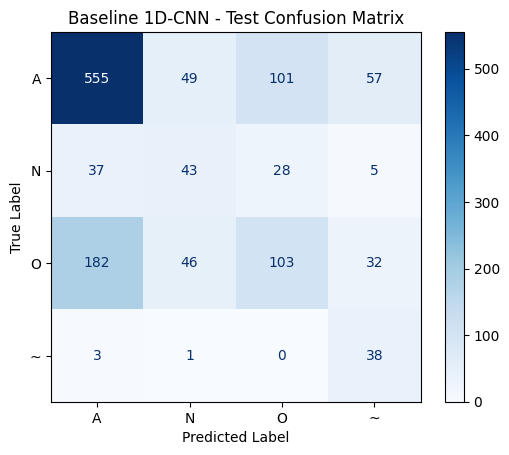

In [25]:
class_names = ["A", "N", "O", "~"]

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", values_format="d")

plt.title("Baseline 1D-CNN - Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [26]:
print("===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           A     0.7143    0.7283    0.7212       762
           N     0.3094    0.3805    0.3413       113
           O     0.4440    0.2837    0.3462       363
           ~     0.2879    0.9048    0.4368        42

    accuracy                         0.5773      1280
   macro avg     0.4389    0.5743    0.4614      1280
weighted avg     0.5879    0.5773    0.5720      1280



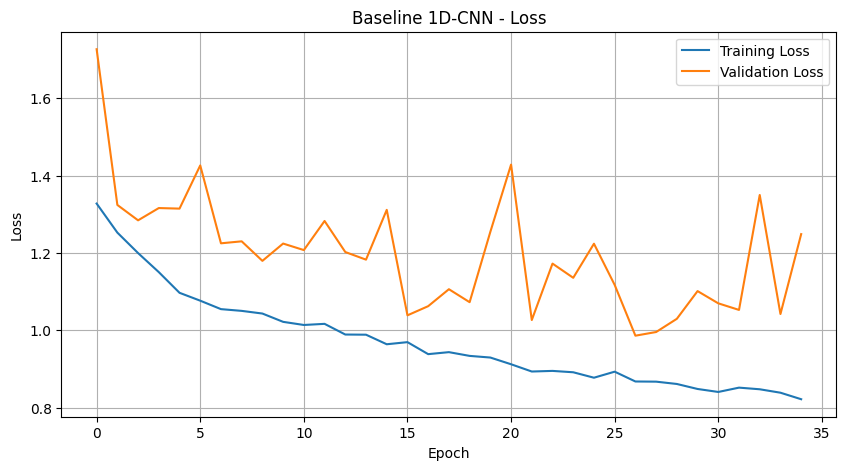

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Baseline 1D-CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

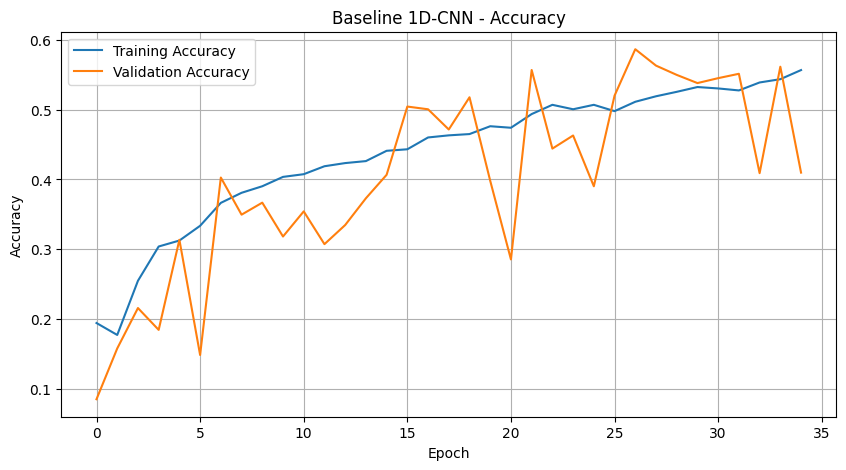

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Baseline 1D-CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

In [29]:
import numpy as np

print("===== ENCODED LABEL DISTRIBUTION =====")

for class_id in np.unique(y_test):
    count = np.sum(y_test == class_id)
    print(f"Encoded class {class_id}: {count} samples")

print("\n===== TRAIN LABEL DISTRIBUTION =====")

for class_id in np.unique(y_train):
    count = np.sum(y_train == class_id)
    print(f"Encoded class {class_id}: {count} samples")

===== ENCODED LABEL DISTRIBUTION =====
Encoded class 0: 762 samples
Encoded class 1: 113 samples
Encoded class 2: 363 samples
Encoded class 3: 42 samples

===== TRAIN LABEL DISTRIBUTION =====
Encoded class 0: 3553 samples
Encoded class 1: 531 samples
Encoded class 2: 1690 samples
Encoded class 3: 195 samples


===== FINAL BASELINE RESULTS =====
Test Accuracy: 0.5773
Macro F1: 0.4614
Weighted F1: 0.5720

===== CONFUSION MATRIX =====
[[555  49 101  57]
 [ 37  43  28   5]
 [182  46 103  32]
 [  3   1   0  38]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.7143    0.7283    0.7212       762
           A     0.3094    0.3805    0.3413       113
           O     0.4440    0.2837    0.3462       363
           ~     0.2879    0.9048    0.4368        42

    accuracy                         0.5773      1280
   macro avg     0.4389    0.5743    0.4614      1280
weighted avg     0.5879    0.5773    0.5720      1280



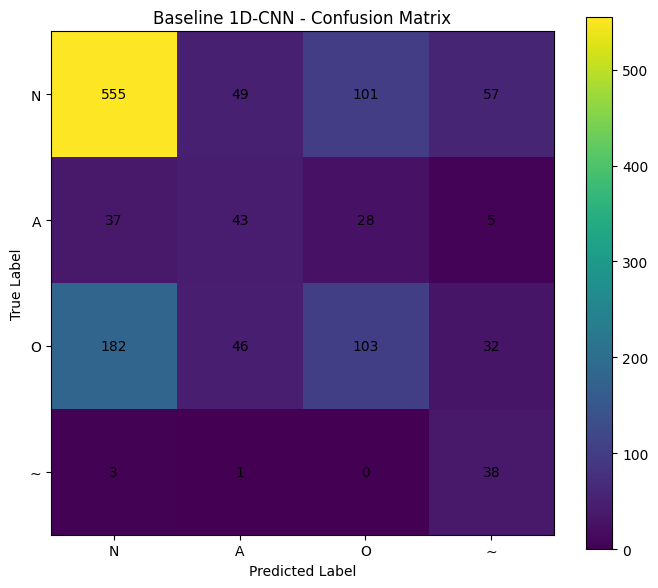

In [30]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PREDICTIONS
# ==============================

y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# ==============================
# CLASS NAMES
# ==============================

class_names = ['N', 'A', 'O', '~']

# ==============================
# ACCURACY
# ==============================

accuracy = accuracy_score(y_test, y_pred)

print("===== FINAL BASELINE RESULTS =====")
print(f"Test Accuracy: {accuracy:.4f}")

# ==============================
# F1 SCORES
# ==============================

macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(f"Macro F1: {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")

# ==============================
# CONFUSION MATRIX
# ==============================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n===== CONFUSION MATRIX =====")
print(cm)

# ==============================
# CLASSIFICATION REPORT
# ==============================

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1, 2, 3],
        target_names=class_names,
        digits=4
    )
)

# ==============================
# CONFUSION MATRIX PLOT
# ==============================

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("Baseline 1D-CNN - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

# نمایش عدد داخل هر خانه
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [31]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

# ==========================================
# EXPERIMENT 1: WITHOUT CLASS WEIGHTS
# ==========================================

model_no_weights = Sequential([
    Conv1D(
        filters=32,
        kernel_size=7,
        activation="relu",
        input_shape=(9000, 1)
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    ),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=128,
        kernel_size=3,
        activation="relu"
    ),

    MaxPooling1D(pool_size=2),

    GlobalAveragePooling1D(),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        4,
        activation="softmax"
    )
])

model_no_weights.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_no_weights.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 8994, 32)          256       
                                                                 
 max_pooling1d_3 (MaxPooling  (None, 4497, 32)         0         
 1D)                                                             
                                                                 
 conv1d_4 (Conv1D)           (None, 4493, 64)          10304     
                                                                 
 max_pooling1d_4 (MaxPooling  (None, 2246, 64)         0         
 1D)                                                             
                                                                 
 conv1d_5 (Conv1D)           (None, 2244, 128)         24704     
                                                                 
 max_pooling1d_5 (MaxPooling  (None, 1122, 128)       

In [32]:
callbacks_no_weights = [
    ModelCheckpoint(
        "best_baseline_no_weights.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

In [33]:
history_no_weights = model_no_weights.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),

    epochs=50,
    batch_size=32,

    callbacks=callbacks_no_weights,

    verbose=1
)

Epoch 1/50
186/187 [============================>.] - ETA: 0s - loss: 1.0440 - accuracy: 0.5912
Epoch 1: val_loss improved from inf to 0.99674, saving model to best_baseline_no_weights.keras
187/187 [==============================] - 10s 51ms/step - loss: 1.0436 - accuracy: 0.5914 - val_loss: 0.9967 - val_accuracy: 0.5950
Epoch 2/50
187/187 [==============================] - ETA: 0s - loss: 0.9851 - accuracy: 0.5952
Epoch 2: val_loss improved from 0.99674 to 0.98177, saving model to best_baseline_no_weights.keras
187/187 [==============================] - 9s 49ms/step - loss: 0.9851 - accuracy: 0.5952 - val_loss: 0.9818 - val_accuracy: 0.5989
Epoch 3/50
186/187 [============================>.] - ETA: 0s - loss: 0.9731 - accuracy: 0.5971
Epoch 3: val_loss improved from 0.98177 to 0.96125, saving model to best_baseline_no_weights.keras
187/187 [==============================] - 9s 49ms/step - loss: 0.9732 - accuracy: 0.5971 - val_loss: 0.9612 - val_accuracy: 0.5989
Epoch 4/50
186/187 [==

In [34]:
from tensorflow.keras.models import load_model

# Load best model
best_model = load_model("best_baseline_no_weights.keras")

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== TEST RESULTS - NO CLASS WEIGHTS =====")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 1s 21ms/step - loss: 0.8176 - accuracy: 0.6508
===== TEST RESULTS - NO CLASS WEIGHTS =====
Test Loss: 0.8176
Test Accuracy: 0.6508


In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predictions
y_prob = best_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

# Class names
class_names = ["N", "A", "O", "~"]

print("===== CONFUSION MATRIX =====")

cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n===== CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

40/40 [==============================] - 1s 25ms/step
===== CONFUSION MATRIX =====
[[699   9  41  13]
 [ 65  24  22   2]
 [249  21  85   8]
 [ 16   0   1  25]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.6793    0.9173    0.7806       762
           A     0.4444    0.2124    0.2874       113
           O     0.5705    0.2342    0.3320       363
           ~     0.5208    0.5952    0.5556        42

    accuracy                         0.6508      1280
   macro avg     0.5538    0.4898    0.4889      1280
weighted avg     0.6225    0.6508    0.6024      1280

